# Customer Behavior Analysis — Alfido Tech

## Project Overview
This project analyzes e-commerce customer transaction data to understand purchasing behavior, customer value, retention, and actionable business opportunities.

### Objectives
- Clean and prepare transaction data
- Explore sales and customer behavior
- Perform RFM (Recency, Frequency, Monetary) analysis
- Segment customers based on RFM scores
- Analyze purchase trends
- Measure cohort retention
- Translate analytical findings into business recommendations

### Tools
**Python • Pandas • NumPy • Matplotlib • Seaborn**


In [47]:
# 1. Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from google.colab import files

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Upload the dataset
uploaded = files.upload()
file_name = next(iter(uploaded))

# Load dataset
df = pd.read_csv(file_name)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 250,000 rows × 13 columns


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


## 2. Data Quality Check

In [48]:
# Data Quality Check

print("Dataset Shape:", df.shape)

print("\nColumn Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (250000, 13)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memor

,Missing Values
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0



Duplicate Rows: 0


## 3. Data Cleaning

In [49]:
# Data Cleaning

df_clean = df.copy()

# Convert Purchase Date to datetime
df_clean["Purchase Date"] = pd.to_datetime(
    df_clean["Purchase Date"],
    errors="coerce"
)

# Fill missing Returns with 0
df_clean["Returns"] = df_clean["Returns"].fillna(0)

# Remove duplicate Age column if present
if "Age" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Age"])

# Remove records with invalid purchase dates
df_clean = df_clean.dropna(subset=["Purchase Date"])

print("Cleaned Dataset Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
display(df_clean.isnull().sum().to_frame("Missing Values"))

display(df_clean.head())

Cleaned Dataset Shape: (250000, 12)

Remaining Missing Values:


,Missing Values
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,Female,1


## 4. Feature Engineering

In [50]:
# Feature Engineering

df_clean["Purchase Year"] = df_clean["Purchase Date"].dt.year
df_clean["Purchase Month"] = df_clean["Purchase Date"].dt.month
df_clean["Purchase Day"] = df_clean["Purchase Date"].dt.day
df_clean["Purchase DayOfWeek"] = df_clean["Purchase Date"].dt.dayofweek
df_clean["Purchase Hour"] = df_clean["Purchase Date"].dt.hour
df_clean["Purchase Day Name"] = df_clean["Purchase Date"].dt.day_name()
df_clean["Purchase Month Name"] = df_clean["Purchase Date"].dt.month_name()

display(
    df_clean[
        [
            "Purchase Date",
            "Purchase Year",
            "Purchase Month",
            "Purchase Day",
            "Purchase DayOfWeek",
            "Purchase Day Name",
            "Purchase Month Name",
            "Purchase Hour"
        ]
    ].head()
)

,Purchase Date,Purchase Year,Purchase Month,Purchase Day,Purchase DayOfWeek,Purchase Day Name,Purchase Month Name,Purchase Hour
0,2020-09-08 09:38:32,2020,9,8,1,Tuesday,September,9
1,2022-03-05 12:56:35,2022,3,5,5,Saturday,March,12
2,2022-05-23 18:18:01,2022,5,23,0,Monday,May,18
3,2020-11-12 13:13:29,2020,11,12,3,Thursday,November,13
4,2020-11-27 17:55:11,2020,11,27,4,Friday,November,17


## 5. Exploratory Data Analysis

In [51]:
# Descriptive Statistics

display(df_clean.describe())

print("Product Category Distribution:")
display(df_clean["Product Category"].value_counts())

print("Payment Method Distribution:")
display(df_clean["Payment Method"].value_counts())

print("Gender Distribution:")
display(df_clean["Gender"].value_counts())

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Churn,Purchase Year,Purchase Month,Purchase Day,Purchase DayOfWeek,Purchase Hour
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.403076,0.199496,2021.377992,6.186388,15.634076,2.996348,11.486784
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,0.000000,2020.000000,1.000000,1.000000,0.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,0.000000,2020.000000,3.000000,8.000000,1.000000,6.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,0.000000,2021.000000,6.000000,16.000000,3.000000,11.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,0.000000,2022.000000,9.000000,23.000000,5.000000,17.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,1.000000,2023.000000,12.000000,31.000000,6.000000,23.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.490517,0.399622,1.077485,3.353738,8.793364,1.997021,6.915558


Product Category Distribution:


,count
Product Category,
Clothing,75052
Books,74912
Electronics,50185
Home,49851


Payment Method Distribution:


,count
Payment Method,
Credit Card,100486
PayPal,74837
Cash,49894
Crypto,24783


Gender Distribution:


,count
Gender,
Female,125560
Male,124440


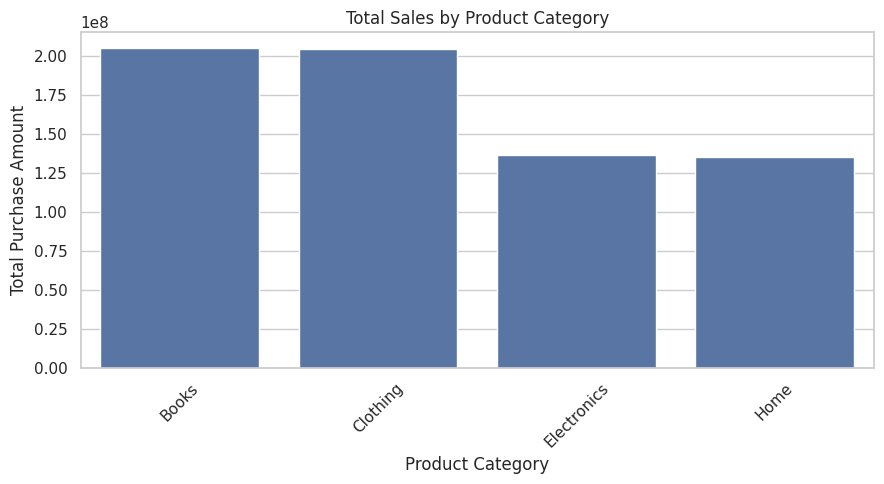

In [52]:
# Sales by Product Category

category_sales = (
    df_clean.groupby("Product Category")["Total Purchase Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

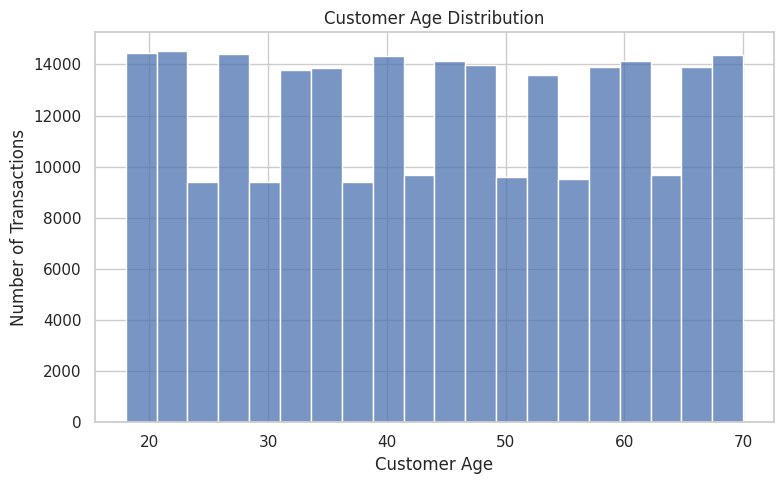

In [53]:
# Customer Age Distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="Customer Age", bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

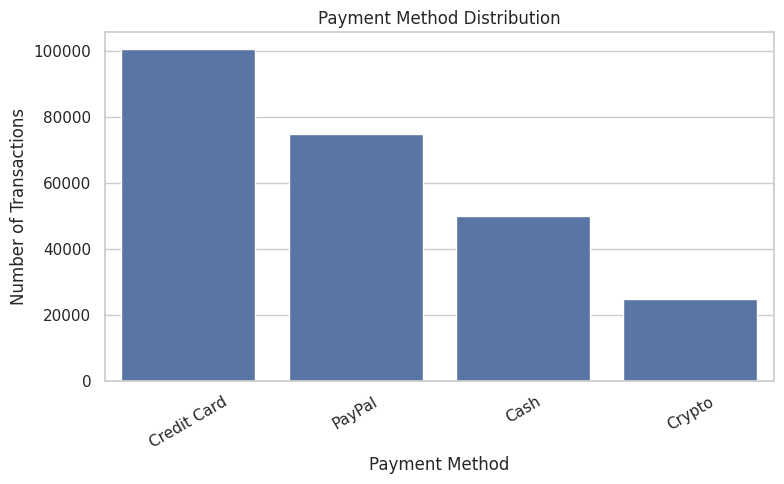

In [54]:
# Payment Method Distribution

payment_counts = df_clean["Payment Method"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_counts.index, y=payment_counts.values)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Purchase Trends

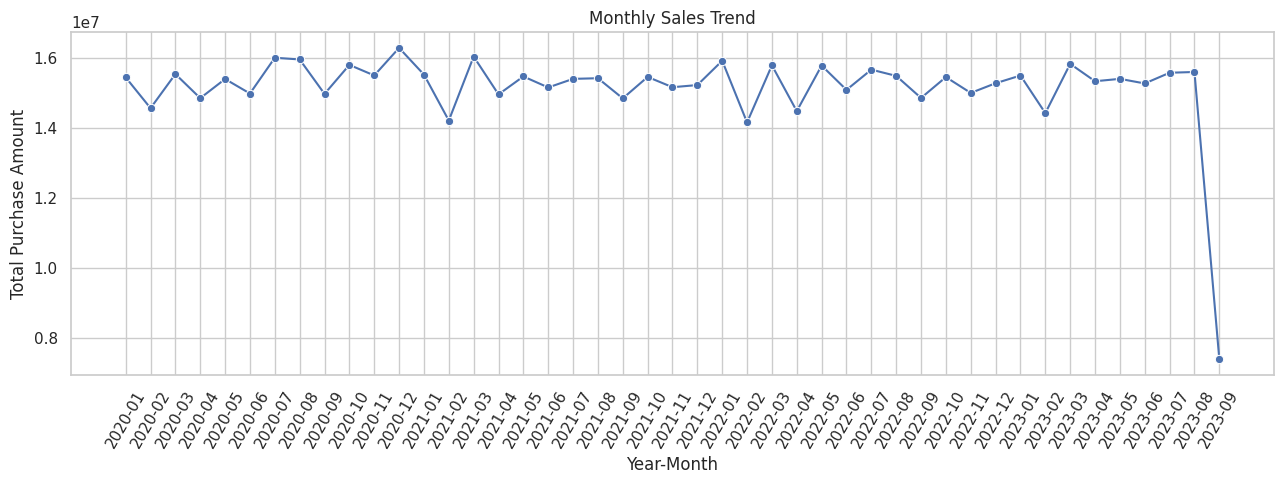

In [55]:
# Monthly Sales Trend

monthly_sales = (
    df_clean.groupby(["Purchase Year", "Purchase Month"])["Total Purchase Amount"]
    .sum()
    .reset_index()
)

monthly_sales["Year-Month"] = (
    monthly_sales["Purchase Year"].astype(str)
    + "-"
    + monthly_sales["Purchase Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(13, 5))
sns.lineplot(
    data=monthly_sales,
    x="Year-Month",
    y="Total Purchase Amount",
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Purchase Amount")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

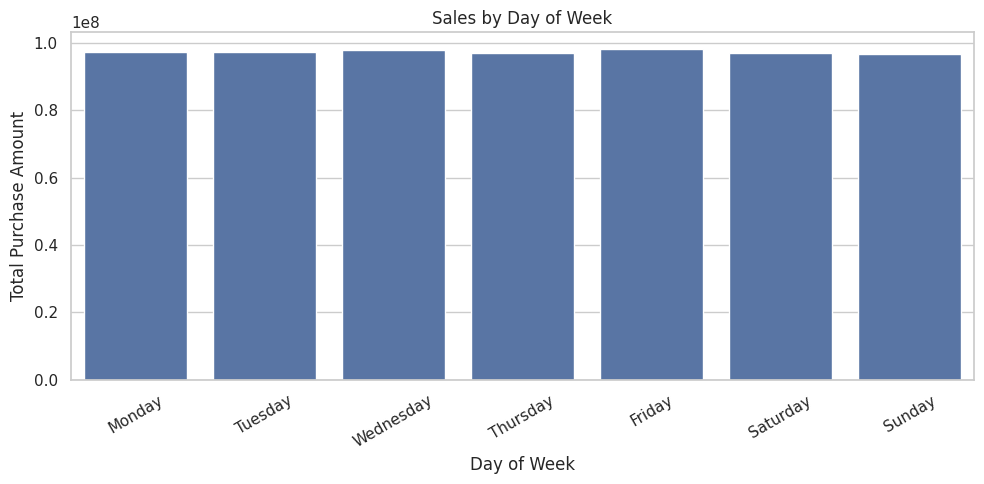

In [56]:
# Sales by Day of Week

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_sales = (
    df_clean.groupby("Purchase Day Name")["Total Purchase Amount"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_sales.index, y=day_sales.values)
plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Purchase Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. RFM Customer Analysis

In [57]:
# Calculate RFM Metrics

reference_date = df_clean["Purchase Date"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean.groupby("Customer ID")
    .agg(
        Recency=("Purchase Date", lambda x: (reference_date - x.max()).days),
        Frequency=("Purchase Date", "count"),
        Monetary=("Total Purchase Amount", "sum")
    )
    .reset_index()
)

print(f"Unique customers analyzed: {rfm['Customer ID'].nunique():,}")
display(rfm.head())

Unique customers analyzed: 49,673


,Customer ID,Recency,Frequency,Monetary
0,1,58,1,3491
1,2,299,3,7988
2,3,89,8,22587
3,4,127,4,8715
4,5,171,8,12524


In [58]:
# Calculate RFM Scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,58,1,3491,5,1,1,7
1,2,299,3,7988,2,1,2,5
2,3,89,8,22587,4,5,5,14
3,4,127,4,8715,4,2,2,8
4,5,171,8,12524,3,5,3,11


In [59]:
# Customer Segmentation
# Thresholds are business rules based on the combined RFM score (3–15).

def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 11:
        return "Loyal Customers"
    elif score >= 9:
        return "Potential Loyalists"
    elif score >= 7:
        return "Customers Needing Attention"
    else:
        return "At Risk"

rfm["Customer Segment"] = rfm["RFM_Score"].apply(segment_customer)

segment_summary = (
    rfm["Customer Segment"]
    .value_counts()
    .rename_axis("Customer Segment")
    .reset_index(name="Customer Count")
)

segment_summary["Percentage"] = (
    segment_summary["Customer Count"] / len(rfm) * 100
).round(2)

display(segment_summary)

,Customer Segment,Customer Count,Percentage
0,At Risk,13376,26.93
1,Champions,9467,19.06
2,Potential Loyalists,9028,18.17
3,Loyal Customers,8951,18.02
4,Customers Needing Attention,8851,17.82


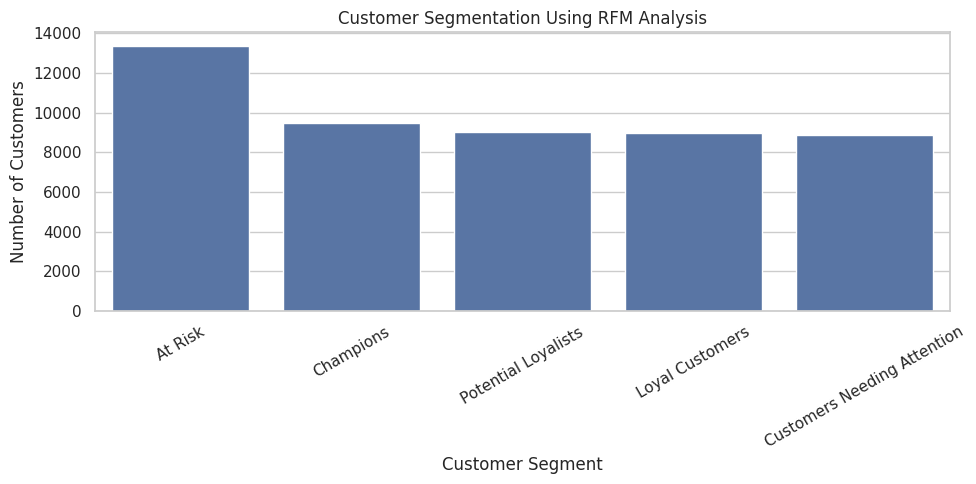

In [60]:
# Customer Segment Distribution

plt.figure(figsize=(10, 5))
sns.barplot(
    data=segment_summary,
    x="Customer Segment",
    y="Customer Count"
)
plt.title("Customer Segmentation Using RFM Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [61]:
# RFM Segment Profile

segment_profile = (
    rfm.groupby("Customer Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .sort_values("Customers", ascending=False)
    .round(2)
)

display(segment_profile)


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Customer Segment,,,,
At Risk,13376,500.30,2.73,6839.61
Champions,9467,76.59,7.93,22633.30
Potential Loyalists,9028,201.32,5.08,13710.85
Loyal Customers,8951,163.16,6.32,17579.15
Customers Needing Attention,8851,258.80,4.06,10671.57


## 8. Cohort & Retention Analysis

Customer Cohort Retention (%)


Cohort Index,1,2,3,4,5,6,7,8,9,10,...,36,37,38,39,40,41,42,43,44,45
First Purchase Month,,,,,,,,,,,,,,,,,,,,,
2020-01,100.0,9.71,10.75,10.23,10.12,11.03,10.84,11.09,10.79,10.96,...,10.31,10.79,10.23,11.25,10.79,10.23,11.01,10.40,11.24,5.08
2020-02,100.0,10.90,10.55,11.51,10.05,11.03,10.68,10.47,11.60,10.29,...,10.25,10.01,10.53,10.18,10.88,10.77,11.01,10.95,4.85,NaN
2020-03,100.0,9.47,10.87,9.86,11.45,9.98,10.54,11.05,11.45,10.35,...,11.52,11.73,10.70,10.17,10.35,10.87,12.15,4.97,NaN,NaN
2020-04,100.0,11.75,10.60,11.00,10.63,10.47,11.19,11.00,11.05,10.84,...,10.58,10.97,9.54,10.55,10.52,10.47,5.62,NaN,NaN,NaN
2020-05,100.0,10.43,10.69,11.30,11.01,11.65,10.81,11.85,10.40,9.39,...,10.95,10.40,9.94,10.90,10.84,5.68,NaN,NaN,NaN,NaN
2020-06,100.0,11.83,10.13,9.10,10.83,11.36,11.03,10.63,10.53,11.40,...,11.10,10.03,10.07,10.56,5.05,NaN,NaN,NaN,NaN,NaN
2020-07,100.0,10.94,10.51,11.36,10.30,10.19,11.33,10.01,11.04,11.26,...,10.51,11.08,10.65,5.50,NaN,NaN,NaN,NaN,NaN,NaN
2020-08,100.0,10.87,11.18,10.98,11.38,10.94,9.53,12.24,11.46,10.16,...,11.42,11.26,5.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09,100.0,9.57,10.31,10.72,10.49,9.25,10.81,10.58,10.63,9.53,...,9.66,5.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


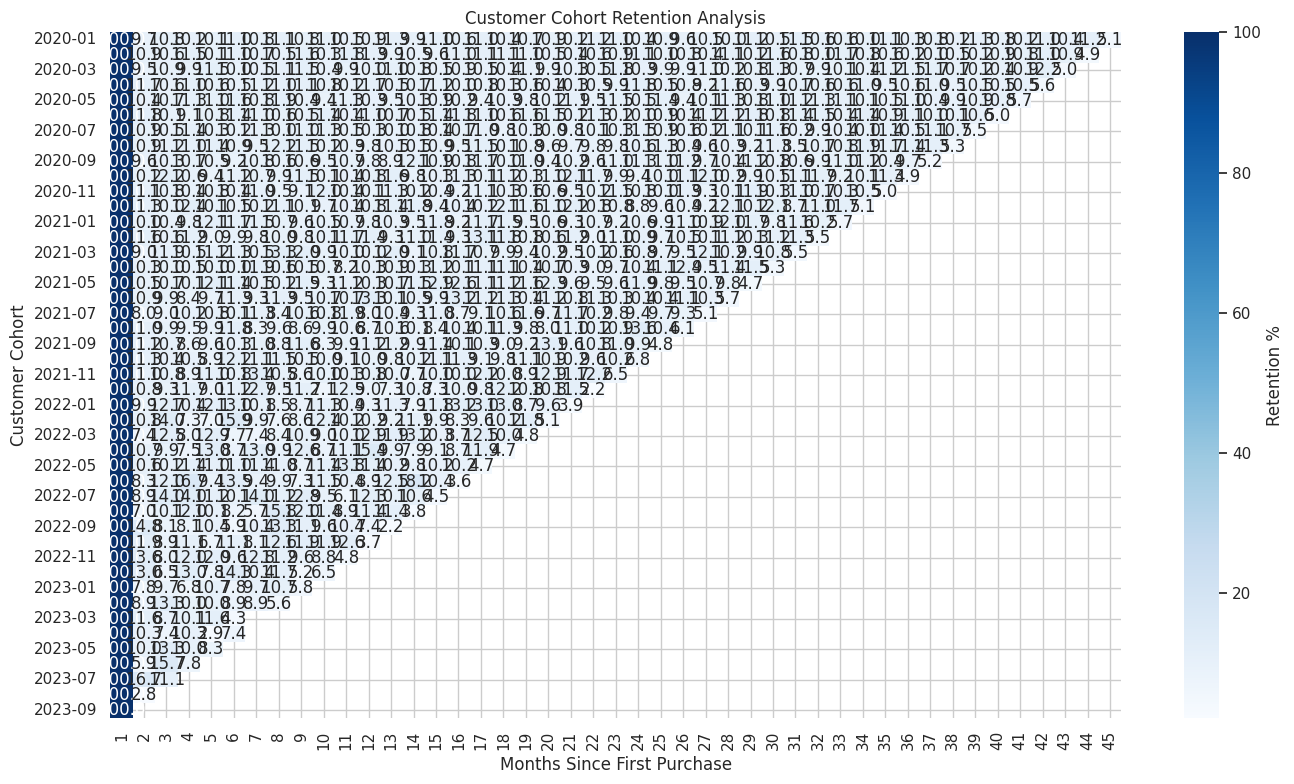

In [63]:
# Cohort & Retention Analysis

cohort_df = df_clean.copy()

cohort_df["First Purchase Month"] = (
    cohort_df.groupby("Customer ID")["Purchase Date"]
    .transform("min")
    .dt.to_period("M")
)

cohort_df["Purchase Month"] = cohort_df["Purchase Date"].dt.to_period("M")

cohort_df["Cohort Index"] = (
    (cohort_df["Purchase Month"].dt.year -
     cohort_df["First Purchase Month"].dt.year) * 12
    +
    (cohort_df["Purchase Month"].dt.month -
     cohort_df["First Purchase Month"].dt.month)
    + 1
)

cohort_counts = (
    cohort_df
    .groupby(["First Purchase Month", "Cohort Index"])["Customer ID"]
    .nunique()
    .reset_index()
)

retention_matrix = cohort_counts.pivot(
    index="First Purchase Month",
    columns="Cohort Index",
    values="Customer ID"
)

retention_matrix_percentage = (
    retention_matrix
    .div(retention_matrix.iloc[:, 0], axis=0)
    * 100
)

print("Customer Cohort Retention (%)")
display(retention_matrix_percentage.round(2))

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_matrix_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Retention %"}
)
plt.title("Customer Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")
plt.tight_layout()
plt.show()

## 9. Key Findings & Business Recommendations

In [64]:
# Key Findings & Business Recommendations

segment_counts = rfm["Customer Segment"].value_counts()
largest_segment = segment_counts.idxmax()
largest_segment_count = segment_counts.max()
largest_segment_pct = largest_segment_count / len(rfm) * 100

top_category = category_sales.index[0]
top_category_sales = category_sales.iloc[0]

top_payment = payment_counts.index[0]
top_payment_count = payment_counts.iloc[0]

if retention_matrix_percentage.shape[1] > 1:
    avg_month_2_retention = retention_matrix_percentage.iloc[:, 1].mean()
else:
    avg_month_2_retention = np.nan

print("=" * 72)
print("KEY FINDINGS")
print("=" * 72)

print(
    f"1. {largest_segment} is the largest customer segment: "
    f"{largest_segment_count:,} customers ({largest_segment_pct:.1f}%)."
)

print(
    f"2. {top_category} generated the highest total sales: "
    f"{top_category_sales:,.2f}."
)

print(
    f"3. {top_payment} was the most frequently used payment method: "
    f"{top_payment_count:,} transactions."
)

if not np.isnan(avg_month_2_retention):
    print(
        f"4. Average second-month cohort retention is "
        f"{avg_month_2_retention:.1f}%."
    )

print("\nBUSINESS RECOMMENDATIONS")
print("-" * 72)

recommendations = [
    "Prioritize retention and reactivation campaigns for At Risk customers.",
    "Reward Champions and Loyal Customers through loyalty benefits and personalized offers.",
    "Use targeted offers to convert Potential Loyalists into Loyal Customers.",
    "Use high-performing product categories for cross-selling and promotional campaigns.",
    "Monitor cohort retention to identify where customer engagement declines.",
    "Optimize the checkout experience around commonly used payment methods."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

KEY FINDINGS
1. At Risk is the largest customer segment: 13,376 customers (26.9%).
2. Books generated the highest total sales: 204,939,601.00.
3. Credit Card was the most frequently used payment method: 100,486 transactions.
4. Average second-month cohort retention is 10.3%.

BUSINESS RECOMMENDATIONS
------------------------------------------------------------------------
1. Prioritize retention and reactivation campaigns for At Risk customers.
2. Reward Champions and Loyal Customers through loyalty benefits and personalized offers.
3. Use targeted offers to convert Potential Loyalists into Loyal Customers.
4. Use high-performing product categories for cross-selling and promotional campaigns.
5. Monitor cohort retention to identify where customer engagement declines.
6. Optimize the checkout experience around commonly used payment methods.


## 10. Conclusion

This analysis combines exploratory analysis, RFM-based customer segmentation, purchase trend analysis, and cohort retention analysis to identify customer-value patterns and retention opportunities.

The results can support targeted retention campaigns, loyalty strategies, reactivation efforts, and data-driven marketing decisions.

### Project Deliverables
- Cleaned and analyzed e-commerce transaction dataset
- Exploratory data analysis and visualizations
- RFM customer segmentation
- Cohort retention analysis
- Business findings and actionable recommendations
